# get full English term list

In [1]:
import pandas as pd
df = pd.read_csv("/home/jiaruil5/multilingual/multilingual-model-card/src/dictionary_collection/growing_dict/mturk_5terms_per_page.csv")
tot_terms = df['English1'].tolist() + df['English2'].tolist() + df['English3'].tolist() + df['English4'].tolist() + df['English5'].tolist()

# get processed

In [30]:
import pandas as pd
import json

lang = "Arabic"

df = pd.read_csv(f"{lang.lower()}_processed.csv")
# df

In [79]:
out_f = open("tot_terms.json", 'w')
json.dump(tot_terms, out_f, ensure_ascii=False, indent=2)
out_f.flush()

# terms not from the 6060 initiative

In [3]:
# terms not from the 6060 initiative
tmp_df = df.loc[df['Input.English'].isin(tot_terms)]
tmp_df.loc[tmp_df[f'Input.{lang}'] != tmp_df['Answer.translation']][f'Input.{lang}'].unique()

array(['十折交叉验证', '1D 卷积', '2范数', ..., '零样本推理', '零样本设置', '零次迁移'],
      dtype=object)

In [31]:
# terms from the 6060 initiative
tmp_df = df.loc[~df['Input.English'].isin(tot_terms)]
# tmp_df.loc[tmp_df[f'Input.{lang}'] != tmp_df['Answer.translation']][f'Input.{lang}'].unique()

In [32]:
# filter chinese
if lang in ['Chinese', 'Japanese']:
    tmp_df['Answer.translation.cleaned'] = tmp_df['Answer.translation'].str.replace(r'\(.*?\)', '', regex=True)
    tmp_df['Answer.translation.cleaned'] = tmp_df['Answer.translation.cleaned'].str.replace(r'（.*?）', '', regex=True)
    tmp_df['Answer.translation.cleaned'] = tmp_df['Answer.translation.cleaned'].str.split(':').str[-1].str.strip()
    tmp_df['Answer.translation.cleaned'] = tmp_df['Answer.translation.cleaned'].str.split('：').str[-1].str.strip()
elif lang in ['Arabic', 'French', 'Russian']:
    tmp_df['Answer.translation.cleaned'] = tmp_df['Answer.translation'].str.replace(r'\(.*?\)', '', regex=True)
    tmp_df['Answer.translation.cleaned'] = tmp_df['Answer.translation.cleaned'].str.split(':').str[-1].str.strip()
tmp_df = tmp_df.loc[tmp_df['Answer.translation.cleaned'] != ""]
# tmp_df.loc[tmp_df['Answer.translation.cleaned'] != tmp_df['Answer.translation']]

/tmp/ipykernel_1795866/1496744309.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df['Answer.translation.cleaned'] = tmp_df['Answer.translation'].str.replace(r'\(.*?\)', '', regex=True)
/tmp/ipykernel_1795866/1496744309.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df['Answer.translation.cleaned'] = tmp_df['Answer.translation.cleaned'].str.split(':').str[-1].str.strip()


In [33]:
def create_ratio_dict(string_list):
    total_count = len(string_list)
    word_counts = {}

    # Count occurrences of each word
    for word in string_list:
        if word in word_counts:
            word_counts[word] += 1
        else:
            word_counts[word] = 1

    # Create a list of dictionaries with word and ratio
    result = [{"word": word, "ratio": count / total_count} for word, count in word_counts.items()]

    # Sort the list by ratio in descending order
    result_sorted = sorted(result, key=lambda x: x['ratio'], reverse=True)

    return result_sorted

def calculate_accuracy_ratio(df):
    unique_words = df['Input.English'].unique()
    result = []

    for word in unique_words:
        subset = df[df['Input.English'] == word]
        
        exact_matches = sum(subset[f'Input.{lang}'] == subset['Answer.translation.cleaned'])
        total = len(subset)
        ratio = exact_matches / total
        result.append({
            "word": word,
            "gold": subset[f'Input.{lang}'].tolist()[0],
            "exact_match_ratio": ratio,
            "prediction_count": total,
            "prediction_ratio": create_ratio_dict(subset['Answer.translation.cleaned'].tolist()),
        })

    # Sort the dictionary by accuracy ratio in descending order
    return result


# Calculate the ratio
accuracy_ratios = calculate_accuracy_ratio(tmp_df)
# accuracy_ratios

In [34]:
pd.DataFrame(accuracy_ratios).to_csv(f"annotation_results_6060/{lang}.csv")

In [6]:
data = pd.DataFrame(accuracy_ratios)
data.sort_values(by='exact_match_ratio', ascending=False, inplace=True)
data

,word,gold,exact_match_ratio,prediction_count,prediction_ratio
2359,initial state,初始状态,1.0,10,"[{'word': '初始状态', 'ratio': 1.0}]"
2700,log probability,对数概率,1.0,10,"[{'word': '对数概率', 'ratio': 1.0}]"
2685,local parameter,局部参数,1.0,4,"[{'word': '局部参数', 'ratio': 1.0}]"
2686,local search,局部搜索,1.0,4,"[{'word': '局部搜索', 'ratio': 1.0}]"
2687,local search method,局部搜索方法,1.0,7,"[{'word': '局部搜索方法', 'ratio': 1.0}]"
...,...,...,...,...,...
232,Floyd-Warshall algorithm,弗洛伊德-沃舍尔算法,0.0,10,"[{'word': '弗洛伊德-沃肖尔算法', 'ratio': 0.4}, {'word'..."
3291,outlier rejection,异常值排除,0.0,9,"[{'word': '异常值拒绝', 'ratio': 0.4444444444444444..."
231,Fleiss' kappa,费利斯kappa,0.0,10,"[{'word': '弗莱斯κ系数', 'ratio': 0.4}, {'word': '弗..."
4264,synchronous context-free grammar,同步上下文无关语法,0.0,9,"[{'word': '同步上下文无关文法', 'ratio': 0.777777777777..."


In [7]:
a = data.loc[data['exact_match_ratio'] == 1.0].shape[0]
print(a, a / data.shape[0])
a = data.loc[data['exact_match_ratio'] >= 0.5].shape[0]
print(a, a / data.shape[0])
data['prediction_first_ratio'] = data['prediction_ratio'].apply(lambda x: x[0]['ratio'] if len(x) > 0 else 0)
a = data.loc[data['prediction_first_ratio'] >= 0.5].shape[0]
print(a, a / data.shape[0])

2320 0.4917337855023315
3449 0.7310300974989402
4403 0.9332344213649851


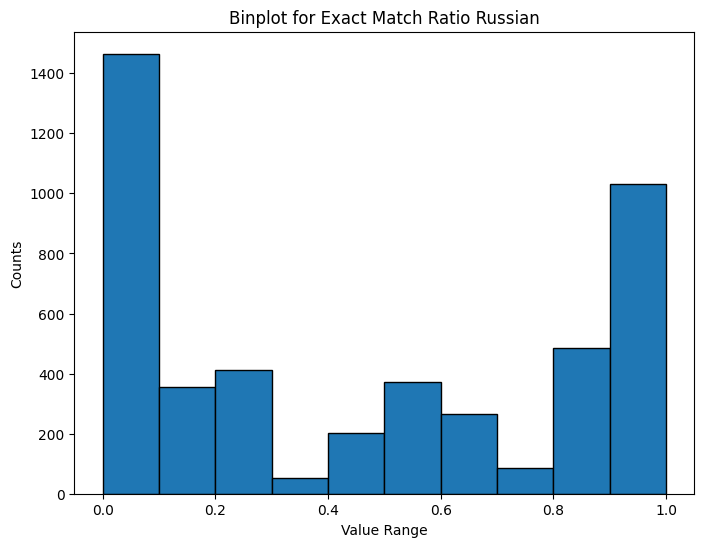

In [93]:
import matplotlib.pyplot as plt

# Sample list of float values from 0 to 1
data_col = data['exact_match_ratio'].tolist()

# Define the bin width
bin_width = 0.1
bins = [i * bin_width for i in range(11)]  # 0.0 to 1.0 in steps of 0.1

# Create the binplot (histogram)
plt.figure(figsize=(8, 6))
plt.hist(data_col, bins=bins, edgecolor='black')

# Add labels and title
plt.xlabel('Value Range')
plt.ylabel('Counts')
plt.title(f'Binplot for Exact Match Ratio {lang}')

# Show the plot
# plt.show()
plt.savefig(f"annotation_results_crawled/binplot_exact_match_ratio_{lang}.jpg", bbox_inches="tight")

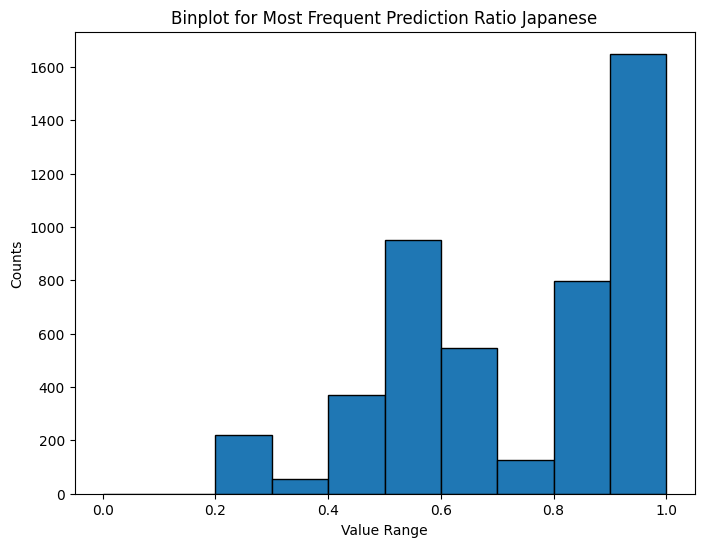

In [128]:
import matplotlib.pyplot as plt

# Sample list of float values from 0 to 1
data_col = data['prediction_first_ratio'].tolist()

# Define the bin width
bin_width = 0.1
bins = [i * bin_width for i in range(11)]  # 0.0 to 1.0 in steps of 0.1

# Create the binplot (histogram)
plt.figure(figsize=(8, 6))
plt.hist(data_col, bins=bins, edgecolor='black')

# Add labels and title
plt.xlabel('Value Range')
plt.ylabel('Counts')
plt.title(f'Binplot for Most Frequent Prediction Ratio {lang}')

# Show the plot
# plt.show()
plt.savefig(f"annotation_results_crawled/binplot_prediction_first_ratio_{lang}.jpg", bbox_inches="tight")

In [8]:
data.sort_values(by='prediction_first_ratio', ascending=False, inplace=True)

In [9]:
pd.DataFrame(data).to_csv(f"annotation_results_crawled/{lang}_data.csv")

In [135]:
pd.DataFrame(accuracy_ratios).to_csv(f"annotation_results_crawled/{lang}.csv")

# terms from the 6060 initiative

In [60]:
tmp_df = df.loc[~df['Input.English'].isin(tot_terms)]
tmp_df.loc[tmp_df[f'Input.{lang}'] != tmp_df['Answer.translation']][f'Input.{lang}'].unique()

array(['AI', 'API', 'AQA', 'ARENA', 'وبالإضافة إلى ذلك', 'AmbigQA',
       'هياكل', 'BART', 'بيرت', 'BERTs', 'BETO', 'BIO', 'BLEU', 'BPE',
       'BSARD', 'CAS', 'CDA', 'CEAS', 'CLIP', 'CLS', 'CoNLL', 'CRF',
       'CamemBERT', 'تجميع', 'CodeBERT', 'كشف', 'حوار', 'إنجليزي', 'FLR',
       'FeSTE', 'ل', 'فرنسي', 'GLUE', 'GPT', 'علاوة على ذلك', 'ومن ثم',
       'ICLR', 'IDF', 'KinyaBERT', 'LXMert', 'LinCE', 'MAWPS', 'MTDNN',
       'MathQA', 'نمذجة', 'وفضلا عن ذلك', 'مورفولوجيا', 'NLI',
       'معالجة اللغة الطبيعية', 'OOV', 'PaLM', 'PubMed', 'ضمان الجودة',
       'QED', 'QUOREF', 'REALM', 'RGF', 'RNSum', 'ROUGE', 'SMCalFlow',
       'SUTD', 'SVAMP', 'الدلاليّة', 'مماثلة', 'لذلك', 'TreeDST', 'VALSE',
       'VFL', 'ViLBERT', 'VisualBERT', 'ويكيبيديا', 'XLM', 'XLNet',
       'استئصال', 'يحقق', 'عدائي', 'خوارزمية', 'خوارزميات', 'تحليل',
       'مشروحة', 'تعليقات توضيحية', 'المعلقين', 'إجابة', 'النهج', 'جانب',
       'تقييم', 'انتباه', 'معزز', 'تلقائي', 'تلقائيًا', 'خطوط الأساس',
       'bia

In [61]:
def calculate_accuracy_ratio(df):
    unique_words = df['Input.English'].unique()
    result = []

    for word in unique_words:
        subset = df[df['Input.English'] == word]
        exact_matches = sum(subset[f'Input.{lang}'] == subset['Answer.translation'])
        total = len(subset)
        ratio = exact_matches / total
        result.append({"word": word, "ratio": ratio, "gold": subset[f'Input.{lang}'].tolist()[0], "prediction": subset['Answer.translation'].tolist()})

    # Sort the dictionary by accuracy ratio in descending order
    result_sorted = sorted(result, key=lambda x: x['ratio'], reverse=True)
    return result_sorted


# Calculate the ratio
accuracy_ratios = calculate_accuracy_ratio(tmp_df)

accuracy_ratios

[{'word': 'evaluation',
  'ratio': 1.0,
  'gold': 'تقييم',
  'prediction': ['تقييم',
   'تقييم',
   'تقييم',
   'تقييم',
   'تقييم',
   'تقييم',
   'تقييم',
   'تقييم',
   'تقييم',
   'تقييم']},
 {'word': 'event',
  'ratio': 1.0,
  'gold': 'حدث',
  'prediction': ['حدث',
   'حدث',
   'حدث',
   'حدث',
   'حدث',
   'حدث',
   'حدث',
   'حدث',
   'حدث',
   'حدث']},
 {'word': 'internet',
  'ratio': 1.0,
  'gold': 'الإنترنت',
  'prediction': ['الإنترنت',
   'الإنترنت',
   'الإنترنت',
   'الإنترنت',
   'الإنترنت',
   'الإنترنت',
   'الإنترنت',
   'الإنترنت']},
 {'word': 'sentence',
  'ratio': 1.0,
  'gold': 'جملة',
  'prediction': ['جملة',
   'جملة',
   'جملة',
   'جملة',
   'جملة',
   'جملة',
   'جملة',
   'جملة']},
 {'word': 'source',
  'ratio': 1.0,
  'gold': 'مصدر',
  'prediction': ['مصدر',
   'مصدر',
   'مصدر',
   'مصدر',
   'مصدر',
   'مصدر',
   'مصدر',
   'مصدر']},
 {'word': 'statistical',
  'ratio': 1.0,
  'gold': 'إحصائي',
  'prediction': ['إحصائي',
   'إحصائي',
   'إحصائي',
   'إحصائ

In [62]:
pd.DataFrame(accuracy_ratios).to_csv(f"annotation_results_6060/{lang}.csv")

In [63]:
tmp_df.loc[tmp_df['Input.English'] == accuracy_ratios[-1]['word']]

,Input.index,WorkerId,Input.Arabic,Input.English,Answer.translation
42829,973,A155OW7UP21THF,اقوال,utterances,العبارات
42834,973,A1WPT6LLCRWMDY,اقوال,utterances,التعابير
42839,973,A1YA58RRBN7NI4,اقوال,utterances,كشف الشذوذ
42844,973,A2OTFVI83FT0QL,اقوال,utterances,الإلقاءات
42849,973,A33S3NQJEHPOMN,اقوال,utterances,التعبيرات
42854,973,A3A6RGC6U41CM5,اقوال,utterances,نطوقات
42859,973,A3HDXVNO786Z0L,اقوال,utterances,التعبيرات
42864,973,A5LL8EKITZLQ0,اقوال,utterances,العبارات
42869,973,AMDP4QV7L82Q,اقوال,utterances,التعابير
